# 03 — Model Training & Selection

**流程**: 加载数据 → 时序划分 → 特征选择(仅训练集) → 全模型超参调优 → 测试集评估 → **选出 Top 3** → 详细验证 → 保存运行记录

**核心功能**:
1. ✅ 特征选择仅在训练集上进行，避免数据泄露
2. ✅ 全部模型调优后，按 Test RMSE 自动选出 Top 3
3. ✅ Top 3 模型做残差图 + 预测散点图验证
4. ✅ 每次运行结果追加到 `outputs/run_history.csv`，重跑时可对比哪次 RMSE 最低

**输入**: `data/raw/train_data.csv`  
**输出**: `outputs/models/*.pkl`, `outputs/run_history.csv`, `outputs/figures/top3_*.png`

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import json
import pandas as pd
import numpy as np
from datetime import datetime

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

from config import DATA_RAW, TARGET, MODEL_DIR, FIG_DIR, RANDOM_STATE
from src.preprocessing import load_and_clean, build_feature_matrix
from src.feature_engineering import compute_ensemble_importance
from src.models import discover_models, save_model

RUN_HISTORY_PATH = MODEL_DIR.parent / "run_history.csv"
TOP_K = 3

# ── 每次运行前可修改此备注，记录本次改了什么 ──
RUN_NOTES = ""

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

## 1. 加载原始数据 & 时序划分

从原始数据重新开始，按时间排序后按 80/20 划分训练集和测试集。  
使用**时序划分**（前 80% 训练、后 20% 测试），确保不会用"未来数据"训练。

In [2]:
df = load_and_clean(DATA_RAW)
df = df.sort_values('startdate').reset_index(drop=True)

X_full, y_full, all_features = build_feature_matrix(df, TARGET)
print(f"Full dataset: X={X_full.shape}, y={y_full.shape}")
print(f"Total features (before selection): {len(all_features)}")

split_idx = int(len(X_full) * 0.8)
X_train_raw, X_test_raw = X_full.iloc[:split_idx], X_full.iloc[split_idx:]
y_train, y_test = y_full.iloc[:split_idx], y_full.iloc[split_idx:]

print(f"\nTrain: {X_train_raw.shape}  (rows 0–{split_idx - 1})")
print(f"Test:  {X_test_raw.shape}  (rows {split_idx}–{len(X_full) - 1})")

/Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/src/preprocessing.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['startdate'] = pd.to_datetime(df['startdate'])
/Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/src/preprocessing.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['year']   = df['startdate'].dt.year
/Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/src/preprocessing.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once u

Full dataset: X=(375734, 242), y=(375734,)
Total features (before selection): 242

Train: (300587, 242)  (rows 0–300586)
Test:  (75147, 242)  (rows 300587–375733)


## 2. 特征选择（仅在训练集上）

使用 Lasso + ElasticNet + RandomForest 集成方法，**仅在训练集上**计算特征重要性。  
测试集完全不参与特征选择，杜绝数据泄露。

In [3]:
selected_score, full_score = compute_ensemble_importance(
    X_train_raw, y_train, top_n=30, use_cache=False
)
selected_features = selected_score.index.tolist()

print(f"\nSelected {len(selected_features)} features (train-only):")
print(selected_features)

X_train = X_train_raw[selected_features]
X_test = X_test_raw[selected_features]
print(f"\nX_train: {X_train.shape}, X_test: {X_test.shape}")

  [1/3] Lasso …
  [2/3] ElasticNet …
  [3/3] RandomForest …
  Top-30 投票 ≥2/3: 25 个特征 (3/3=5, 2/3=20)
  Cached scores to /Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/outputs/cache/

Selected 25 features (train-only):
['contest-slp-14d__slp', 'contest-wind-h500-14d__wind-hgt-500', 'nmme-tmp2m-34w__gfdlflorb', 'nmme-tmp2m-34w__cfsv2', 'nmme-tmp2m-56w__cfsv2', 'nmme-tmp2m-56w__gfdlflorb', 'contest-wind-h850-14d__wind-hgt-850', 'nmme-tmp2m-56w__nasa', 'nmme-tmp2m-56w__gfdlflora', 'nmme-tmp2m-34w__nasa', 'elevation__elevation', 'nmme-tmp2m-34w__gfdlflora', 'contest-wind-h100-14d__wind-hgt-100', 'lon', 'contest-pres-sfc-gauss-14d__pres', 'contest-rhum-sig995-14d__rhum', 'contest-wind-vwnd-925-14d__wind-vwnd-925', 'wind-vwnd-925-2010-8', 'wind-hgt-10-2010-9', 'contest-wind-uwnd-925-14d__wind-uwnd-925', 'icec-2010-8', 'wind-hgt-10-2010-7', 'sst-2010-5', 'wind-uwnd-250-2010-10', 'wind-uwnd-250-2010-18']

X_train: (300587, 25), X_test: (75147, 25)


## 3. 超参数调优（所有模型）

对所有模型做 `RandomizedSearchCV`，使用 `TimeSeriesSplit` 作为交叉验证策略。  
**优化策略**：用训练集最近 30% 的数据做调参（时序上最接近测试集，更有代表性），3 折 CV，找到最优参数后再用全量训练集训练。

In [4]:
registry = discover_models()
print(f"Discovered {len(registry)} models: {list(registry.keys())}")

TUNE_FRAC = 0.2
N_ITER = 8

tune_size = int(len(X_train) * TUNE_FRAC)
X_tune = X_train.iloc[-tune_size:]
y_tune = y_train.iloc[-tune_size:]
print(f"Tuning subset: {X_tune.shape} (last {TUNE_FRAC:.0%} of train)\n")

tscv_tune = TimeSeriesSplit(n_splits=3)
tuned_pipelines = {}
tuning_info = {}

for name, entry in registry.items():
    grid = entry.param_grid()
    if not grid:
        print(f"[{name}] No param_grid, keeping default.\n")
        tuned_pipelines[name] = entry.build_pipeline()
        tuning_info[name] = {"cv_rmse": None, "best_params": {}}
        continue

    print(f"[{name}] Tuning ({len(grid)} param groups, n_iter={N_ITER})...")
    search = RandomizedSearchCV(
        entry.build_pipeline(), grid,
        n_iter=N_ITER, cv=tscv_tune,
        scoring='neg_mean_squared_error',
        n_jobs=-1, random_state=RANDOM_STATE, verbose=0,
    )
    search.fit(X_tune, y_tune)
    cv_rmse = np.sqrt(-search.best_score_)
    print(f"  CV RMSE: {cv_rmse:.4f}")
    print(f"  Params:  {search.best_params_}\n")
    tuned_pipelines[name] = search.best_estimator_
    tuning_info[name] = {
        "cv_rmse": round(cv_rmse, 4),
        "best_params": search.best_params_,
    }

print(f"Done. Tuned {len(tuned_pipelines)} models.")

Discovered 6 models: ['catboost', 'elasticnet', 'lasso', 'lightgbm', 'random_forest', 'xgboost']
Tuning subset: (60117, 25) (last 20% of train)

[catboost] Tuning (2 param groups, n_iter=8)...
  CV RMSE: 2.1162
  Params:  {'model__learning_rate': 0.1, 'model__depth': 4}

[elasticnet] Tuning (2 param groups, n_iter=8)...
  CV RMSE: 1.9883
  Params:  {'model__l1_ratio': 0.8, 'model__alpha': 0.01}

[lasso] Tuning (1 param groups, n_iter=8)...


/Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/.venv/lib/python3.13/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 5 is smaller than n_iter=8. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  CV RMSE: 1.9813
  Params:  {'model__alpha': 0.01}

[lightgbm] Tuning (3 param groups, n_iter=8)...


/Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/zhangjiay

  CV RMSE: 2.3434
  Params:  {'model__num_leaves': 15, 'model__n_estimators': 800, 'model__learning_rate': 0.1}

[random_forest] Tuning (3 param groups, n_iter=8)...
  CV RMSE: 2.8583
  Params:  {'model__n_estimators': 200, 'model__min_samples_leaf': 5, 'model__max_depth': 10}

[xgboost] Tuning (3 param groups, n_iter=8)...
  CV RMSE: 2.3963
  Params:  {'model__n_estimators': 1000, 'model__max_depth': 4, 'model__learning_rate': 0.1}

Done. Tuned 6 models.


## 4. 测试集评估 → 选出 Top 3

用调参后的最优参数在**全量训练集**上训练，然后在 **20% 测试集**上评估。  
按 Test RMSE 排序，自动选出表现最好的 **Top 3** 模型。

In [5]:
test_rows = []
predictions = {}

for name, pipe in tuned_pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    test_rows.append({
        'Model': name,
        'Test RMSE': round(rmse, 4),
        'Test R²': round(r2, 4),
    })
    predictions[name] = y_pred
    print(f"[{name}] RMSE={rmse:.4f}, R²={r2:.4f}")

all_results = pd.DataFrame(test_rows).set_index('Model').sort_values('Test RMSE')

top3_names = all_results.head(TOP_K).index.tolist()
print(f"\n{'='*55}")
print(f"  ★ Top {TOP_K} models: {top3_names}")
print(f"{'='*55}")
all_results

[catboost] RMSE=1.9761, R²=0.9033
[elasticnet] RMSE=1.8873, R²=0.9118
[lasso] RMSE=1.8935, R²=0.9113


/Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[lightgbm] RMSE=1.9757, R²=0.9034
[random_forest] RMSE=2.0438, R²=0.8966
[xgboost] RMSE=1.9799, R²=0.9030

  ★ Top 3 models: ['elasticnet', 'lasso', 'lightgbm']


,Test RMSE,Test R²
Model,,
elasticnet,1.8873,0.9118
lasso,1.8935,0.9113
lightgbm,1.9757,0.9034
catboost,1.9761,0.9033
xgboost,1.9799,0.9030
random_forest,2.0438,0.8966


## 5. Top 3 详细验证

对选出的 Top 3 模型做 **预测 vs 实际散点图** 和 **残差分布图**，直观检查模型表现。

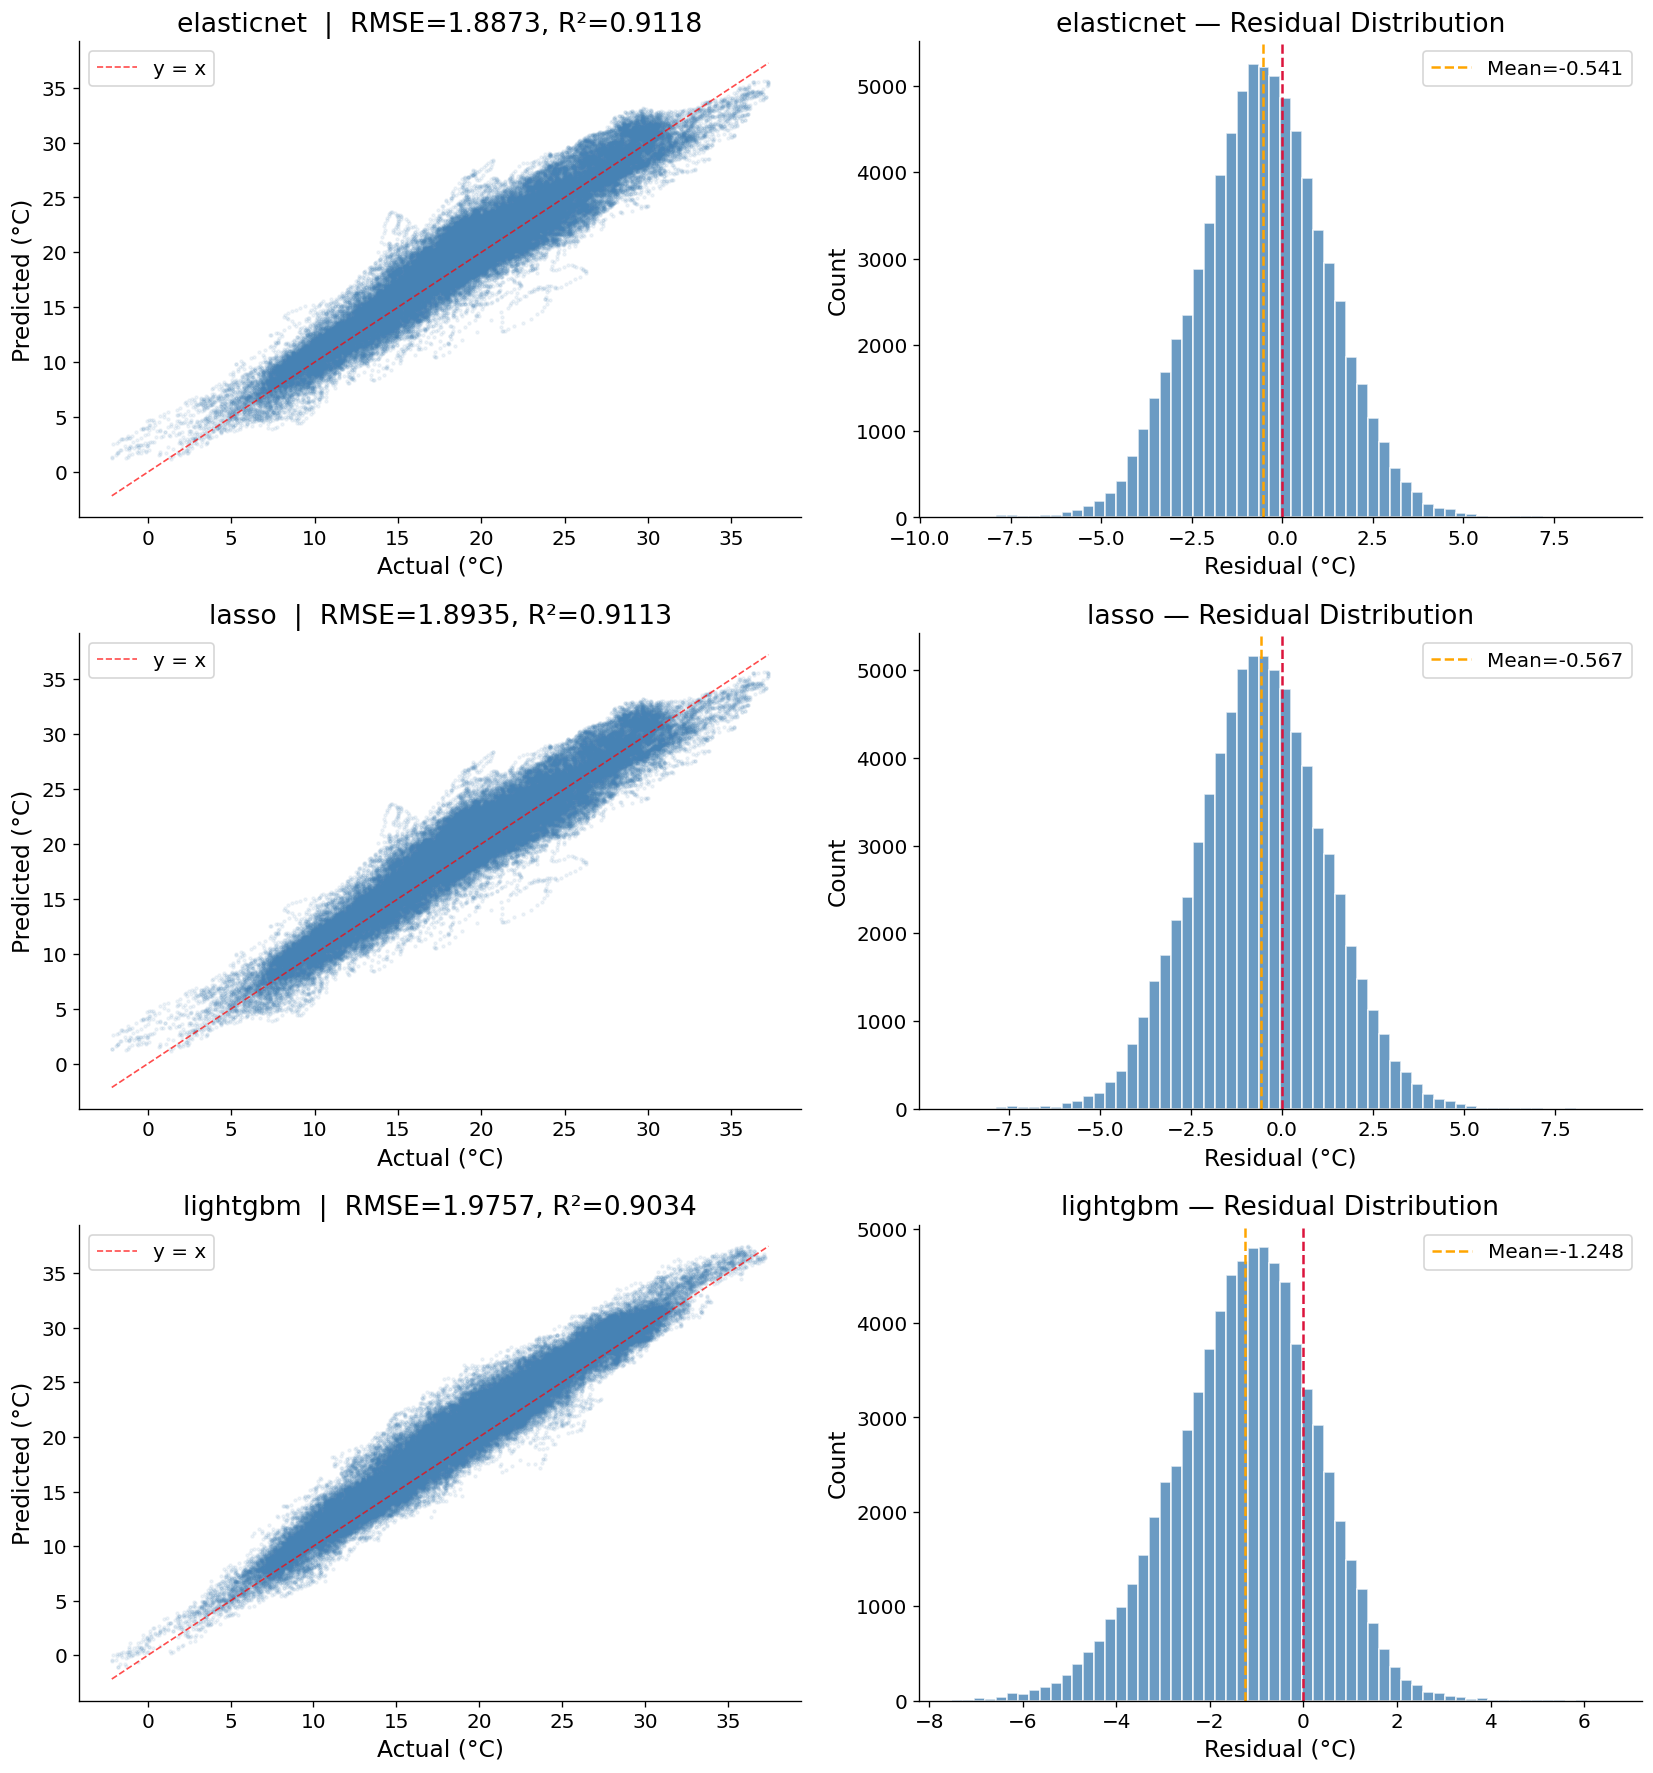

Saved → /Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/outputs/figures/top3_validation.png


In [6]:
fig, axes = plt.subplots(TOP_K, 2, figsize=(14, 5 * TOP_K))
if TOP_K == 1:
    axes = axes.reshape(1, -1)

for i, name in enumerate(top3_names):
    y_pred = predictions[name]
    residuals = y_test.values - y_pred
    rmse_val = all_results.loc[name, 'Test RMSE']
    r2_val = all_results.loc[name, 'Test R²']

    ax = axes[i, 0]
    ax.scatter(y_test, y_pred, alpha=0.08, s=3, color='steelblue')
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1, alpha=0.7, label='y = x')
    ax.set_xlabel('Actual (°C)')
    ax.set_ylabel('Predicted (°C)')
    ax.set_title(f'{name}  |  RMSE={rmse_val}, R²={r2_val}')
    ax.legend(loc='upper left')

    ax = axes[i, 1]
    ax.hist(residuals, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(0, color='crimson', linestyle='--', linewidth=1.5)
    ax.axvline(residuals.mean(), color='orange', linestyle='--',
               label=f'Mean={residuals.mean():.3f}')
    ax.set_xlabel('Residual (°C)')
    ax.set_ylabel('Count')
    ax.set_title(f'{name} — Residual Distribution')
    ax.legend()

plt.tight_layout()
FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(FIG_DIR / 'top3_validation.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved → {FIG_DIR / 'top3_validation.png'}")

## 5.5 Ensemble Blending: ElasticNet + CatBoost

线性模型（ElasticNet）擅长捕获 NMME 等特征与目标的线性信号，树模型（CatBoost）能补充非线性交互。  
通过加权融合 `y = w × ElasticNet + (1−w) × CatBoost`，在两者之间寻找最优平衡点。

In [ ]:
enet_pred = predictions['elasticnet']
cat_pred  = predictions['catboost']

weights = np.arange(0.0, 1.05, 0.05)
blend_rows = []
for w in weights:
    blended = w * enet_pred + (1 - w) * cat_pred
    rmse = np.sqrt(mean_squared_error(y_test, blended))
    r2 = r2_score(y_test, blended)
    blend_rows.append({'w_enet': round(w, 2), 'RMSE': round(rmse, 4), 'R²': round(r2, 4)})

blend_df = pd.DataFrame(blend_rows)
best_idx = blend_df['RMSE'].idxmin()
best_w = blend_df.loc[best_idx, 'w_enet']
best_rmse = blend_df.loc[best_idx, 'RMSE']
best_r2 = blend_df.loc[best_idx, 'R²']

enet_rmse = all_results.loc['elasticnet', 'Test RMSE']
cat_rmse  = all_results.loc['catboost', 'Test RMSE']

print(f"Best weight: ElasticNet={best_w:.2f}, CatBoost={1 - best_w:.2f}")
print(f"Ensemble  RMSE = {best_rmse:.4f},  R² = {best_r2:.4f}")
print(f"ElasticNet RMSE = {enet_rmse:.4f}")
print(f"CatBoost   RMSE = {cat_rmse:.4f}")
print(f"Improvement over ElasticNet: {enet_rmse - best_rmse:+.4f}")

# ── 可视化 ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(blend_df['w_enet'], blend_df['RMSE'], 'o-', ms=4, color='steelblue')
ax1.axhline(enet_rmse, ls='--', color='green', alpha=0.7, label=f'ElasticNet ({enet_rmse})')
ax1.axhline(cat_rmse, ls='--', color='orange', alpha=0.7, label=f'CatBoost ({cat_rmse})')
ax1.axvline(best_w, ls=':', color='red', alpha=0.6, label=f'Best w={best_w:.2f}')
ax1.scatter([best_w], [best_rmse], color='red', s=80, zorder=5)
ax1.set_xlabel('Weight for ElasticNet')
ax1.set_ylabel('Test RMSE')
ax1.set_title('Ensemble Blending: RMSE vs Weight')
ax1.legend()

blended_best = best_w * enet_pred + (1 - best_w) * cat_pred
ax2.scatter(y_test, blended_best, alpha=0.08, s=3, color='steelblue')
lims = [min(y_test.min(), blended_best.min()), max(y_test.max(), blended_best.max())]
ax2.plot(lims, lims, 'r--', linewidth=1, alpha=0.7, label='y = x')
ax2.set_xlabel('Actual (°C)')
ax2.set_ylabel('Predicted (°C)')
ax2.set_title(f'Ensemble (w={best_w:.2f})  |  RMSE={best_rmse}, R²={best_r2}')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.savefig(FIG_DIR / 'ensemble_blending.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved → {FIG_DIR / 'ensemble_blending.png'}")

## 5.5 收敛性检查

对**所有梯度提升模型**（CatBoost / XGBoost / LightGBM），用验证集重新训练并画 **训练 vs 验证 RMSE 曲线**。  
- 曲线末端趋于平坦 → 已收敛  
- 曲线末端仍在明显下降 → 可尝试增大 `iterations` / `n_estimators`  
- 验证曲线反而上升 → 过拟合，需降低复杂度

线性模型（Lasso / ElasticNet）和 RandomForest 不需要这种检查。

/var/folders/r4/kf2r2vts1plbvgy_6v4x68s00000gn/T/ipykernel_56650/4154762731.py:104: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/r4/kf2r2vts1plbvgy_6v4x68s00000gn/T/ipykernel_56650/4154762731.py:104: UserWarning: Glyph 24050 (\N{CJK UNIFIED IDEOGRAPH-5DF2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/r4/kf2r2vts1plbvgy_6v4x68s00000gn/T/ipykernel_56650/4154762731.py:104: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/r4/kf2r2vts1plbvgy_6v4x68s00000gn/T/ipykernel_56650/4154762731.py:104: UserWarning: Glyph 25947 (\N{CJK UNIFIED IDEOGRAPH-655B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/r4/kf2r2vts1plbvgy_6v4x68s00000gn/T/ipykernel_56650/4154762731.py:105: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(FIG_DIR / 'convergence_check.png

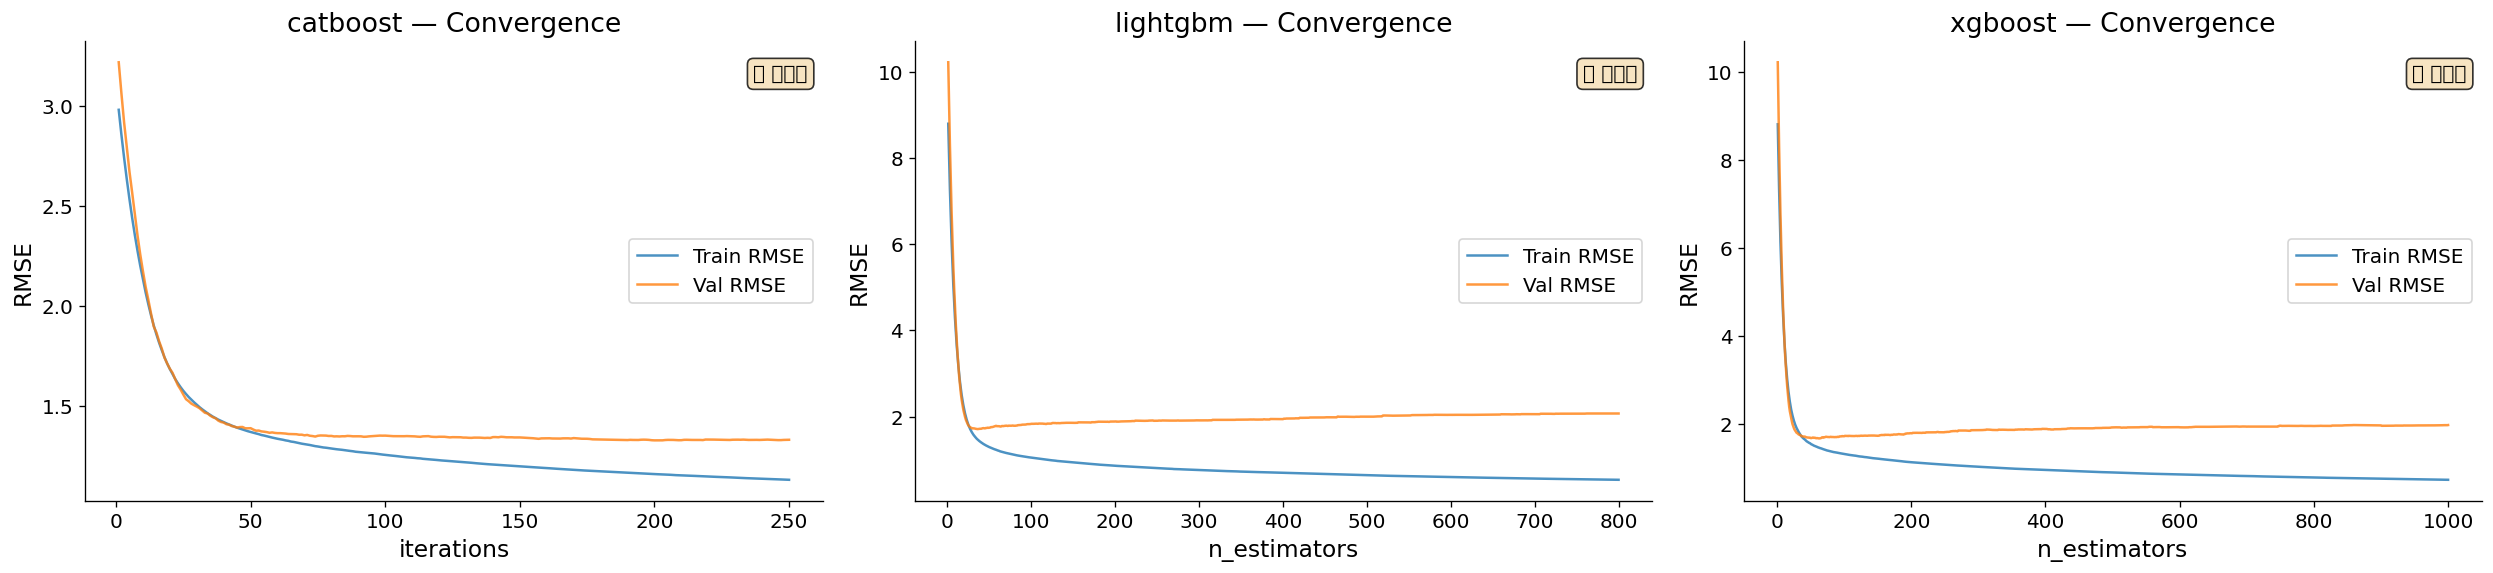

Saved → /Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/outputs/figures/convergence_check.png


In [7]:
from sklearn.preprocessing import StandardScaler

boosting_models = {
    'catboost':  'iterations',
    'xgboost':   'n_estimators',
    'lightgbm':  'n_estimators',
}

all_boosting = [n for n in tuned_pipelines if n in boosting_models]

if not all_boosting:
    print("没有梯度提升模型，跳过收敛检查。")
else:
    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_train)
    X_te_sc = scaler.transform(X_test)

    fig, axes = plt.subplots(1, len(all_boosting),
                             figsize=(7 * len(all_boosting), 5))
    if len(all_boosting) == 1:
        axes = [axes]

    for ax, name in zip(axes, all_boosting):
        pipe = tuned_pipelines[name]
        best_params = tuning_info[name]['best_params']
        inner_model = pipe.named_steps['model']
        params = inner_model.get_params()

        if name == 'catboost':
            from catboost import CatBoostRegressor
            n_rounds = params.get('iterations', 500)
            model = CatBoostRegressor(
                **{k.replace('model__', ''): v for k, v in best_params.items()
                   if k.startswith('model__')},
                iterations=n_rounds, verbose=0, random_seed=42,
                eval_metric='RMSE',
            )
            # use remaining params from tuned model
            model.set_params(**{k: v for k, v in params.items()
                                if k not in ('iterations', 'verbose', 'random_seed',
                                             'eval_metric')
                                and not k.startswith('_')})
            model.fit(X_tr_sc, y_train,
                      eval_set=(X_te_sc, y_test), verbose=0)
            train_rmse = [x ** 0.5 if x > 0 else x
                          for x in model.evals_result_['learn']['RMSE']]
            val_rmse = [x ** 0.5 if x > 0 else x
                        for x in model.evals_result_['validation']['RMSE']]

        elif name == 'xgboost':
            from xgboost import XGBRegressor
            n_rounds = params.get('n_estimators', 500)
            model = XGBRegressor(
                n_estimators=n_rounds,
                max_depth=params.get('max_depth', 6),
                learning_rate=params.get('learning_rate', 0.1),
                n_jobs=-1, random_state=42, verbosity=0,
                eval_metric='rmse',
            )
            model.fit(X_tr_sc, y_train,
                      eval_set=[(X_tr_sc, y_train), (X_te_sc, y_test)],
                      verbose=False)
            res = model.evals_result()
            train_rmse = res['validation_0']['rmse']
            val_rmse = res['validation_1']['rmse']

        elif name == 'lightgbm':
            from lightgbm import LGBMRegressor
            n_rounds = params.get('n_estimators', 500)
            model = LGBMRegressor(
                n_estimators=n_rounds,
                max_depth=params.get('max_depth', 6),
                learning_rate=params.get('learning_rate', 0.1),
                n_jobs=-1, random_state=42, verbose=-1,
            )
            model.fit(X_tr_sc, y_train,
                      eval_set=[(X_tr_sc, y_train), (X_te_sc, y_test)],
                      eval_metric='rmse')
            train_rmse = [x[1] for x in model.evals_result_['training']['rmse']] \
                if isinstance(model.evals_result_['training']['rmse'][0], tuple) \
                else model.evals_result_['training']['rmse']
            val_rmse = model.evals_result_['valid_1']['rmse']

        iters = range(1, len(train_rmse) + 1)
        ax.plot(iters, train_rmse, label='Train RMSE', linewidth=1.5, alpha=0.8)
        ax.plot(iters, val_rmse, label='Val RMSE', linewidth=1.5, alpha=0.8)
        ax.set_xlabel(boosting_models[name])
        ax.set_ylabel('RMSE')
        ax.set_title(f'{name} — Convergence')
        ax.legend()

        last_5_val = val_rmse[-5:]
        delta = last_5_val[0] - last_5_val[-1]
        if delta < 0.001:
            verdict = "✅ 已收敛"
        elif delta < 0.01:
            verdict = "⚠️ 接近收敛，可适当增加轮次"
        else:
            verdict = "❌ 未收敛，建议增大 iterations/n_estimators"
        ax.text(0.98, 0.95, verdict, transform=ax.transAxes,
                ha='right', va='top', fontsize=12,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.8))

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'convergence_check.png', bbox_inches='tight', dpi=150)
    plt.show()
    print(f"Saved → {FIG_DIR / 'convergence_check.png'}")

## 6. 保存模型 & 运行记录

- Top 3 模型保存到 `outputs/models/<run_id>/` 子目录，**不会覆盖**历史运行
- 本次运行的**所有模型**结果追加到 `outputs/run_history.csv`
- 恢复某次历史模型: `load_model("catboost", run_id="20260310_231542")`

In [8]:
run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
run_ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

# ── 保存 Top 3 模型到 run_id 子目录 ──
for name in top3_names:
    save_model(tuned_pipelines[name], name, run_id=run_id)
print(f"Saved top 3 models → {MODEL_DIR / run_id}/")

run_dir = MODEL_DIR / run_id
features_path = run_dir / "selected_features.json"
with open(features_path, 'w') as f:
    json.dump(selected_features, f, indent=2)
print(f"Saved features → {features_path}")

# ── 构建运行记录 ──
history_rows = []
for name in all_results.index:
    info = tuning_info.get(name, {})
    history_rows.append({
        'run_id': run_id,
        'timestamp': run_ts,
        'model': name,
        'best_params': json.dumps(info.get('best_params', {})),
        'cv_rmse': info.get('cv_rmse', None),
        'test_rmse': all_results.loc[name, 'Test RMSE'],
        'test_r2': all_results.loc[name, 'Test R²'],
        'n_features': len(selected_features),
        'is_top3': name in top3_names,
        'notes': RUN_NOTES,
    })

new_rows = pd.DataFrame(history_rows)
if RUN_HISTORY_PATH.exists():
    history = pd.concat([pd.read_csv(RUN_HISTORY_PATH), new_rows], ignore_index=True)
else:
    history = new_rows
history.to_csv(RUN_HISTORY_PATH, index=False)

print(f"\n{'='*55}")
print(f"  Run [{run_id}] saved to {RUN_HISTORY_PATH}")
print(f"  Total runs in history: {history['run_id'].nunique()}")
print(f"{'='*55}")

Saved top 3 models → /Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/outputs/models/20260311_072118/
Saved features → /Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/outputs/models/20260311_072118/selected_features.json

  Run [20260311_072118] saved to /Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/outputs/run_history.csv
  Total runs in history: 5


## 7. 历史运行对比

加载所有历史运行记录，表格展示每次 run 的最佳模型，多次运行时还会画 RMSE 变化趋势图。  
**使用方式**: 修改参数后重跑整个 notebook，这里会自动对比所有历史结果。

Total runs in history: 5

Best model per run (sorted by Test RMSE):


,run_id,timestamp,model,cv_rmse,test_rmse,test_r2,n_features,notes
0,20260311_004518,2026-03-11 00:45:18,elasticnet,1.9883,1.8873,0.9118,25,NaN
1,20260311_011610,2026-03-11 01:16:10,elasticnet,1.9883,1.8873,0.9118,25,NaN
2,20260311_072118,2026-03-11 07:21:18,elasticnet,1.9883,1.8873,0.9118,25,NaN
3,20260310_231542,2026-03-10 23:15:42,elasticnet,1.5607,1.8879,0.9118,25,NaN
4,20260310_235435,2026-03-10 23:54:35,elasticnet,1.5607,1.8879,0.9118,25,NaN



★ Historical best: run [20260311_004518] model=elasticnet, Test RMSE=1.8873


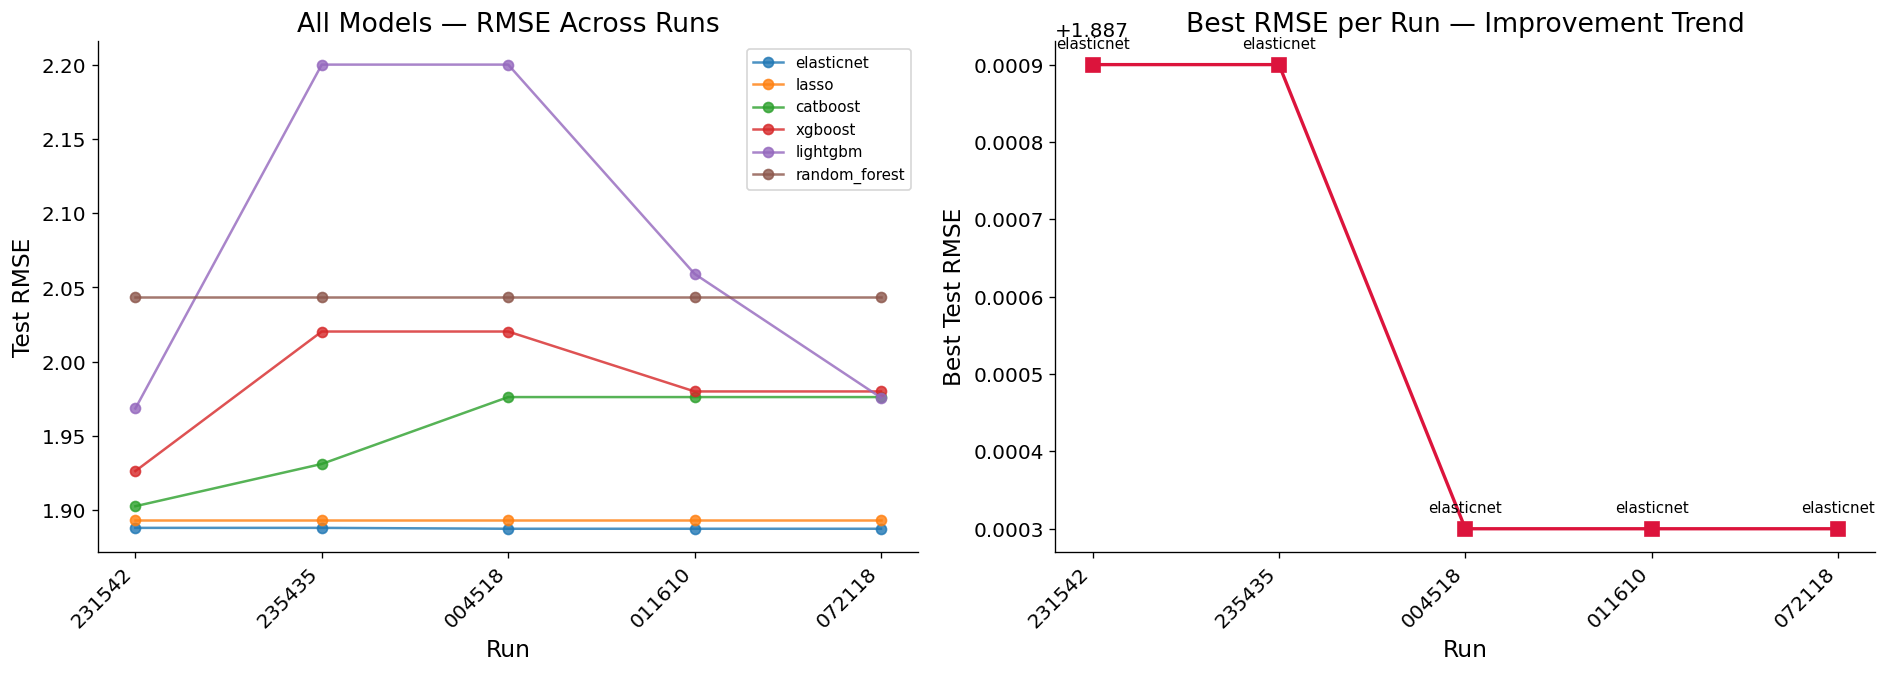

Saved → /Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/outputs/figures/rmse_history.png


In [9]:
history = pd.read_csv(RUN_HISTORY_PATH)
n_runs = history['run_id'].nunique()
print(f"Total runs in history: {n_runs}\n")

# ── 每次 run 的最佳模型 ──
best_per_run = history.loc[history.groupby('run_id')['test_rmse'].idxmin()]
best_per_run = best_per_run[[
    'run_id', 'timestamp', 'model', 'cv_rmse',
    'test_rmse', 'test_r2', 'n_features', 'notes',
]].sort_values('test_rmse')

print("Best model per run (sorted by Test RMSE):")
display(best_per_run.reset_index(drop=True))

global_best = best_per_run.iloc[0]
print(f"\n★ Historical best: run [{global_best['run_id']}] "
      f"model={global_best['model']}, "
      f"Test RMSE={global_best['test_rmse']}")

# ── 多次运行时画趋势图 ──
if n_runs > 1:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # (a) 所有模型 RMSE 跨 run 对比
    ax = axes[0]
    for model_name in history['model'].unique():
        md = history[history['model'] == model_name].sort_values('run_id')
        ax.plot(range(len(md)), md['test_rmse'].values,
                'o-', label=model_name, markersize=6, alpha=0.8)
    ax.set_xticks(range(n_runs))
    ax.set_xticklabels([rid[-6:] for rid in history['run_id'].unique()],
                       rotation=45, ha='right')
    ax.set_xlabel('Run')
    ax.set_ylabel('Test RMSE')
    ax.set_title('All Models — RMSE Across Runs')
    ax.legend(fontsize=9, loc='upper right')

    # (b) 每次 run 的最低 RMSE 趋势
    ax = axes[1]
    bpr = best_per_run.sort_values('run_id')
    ax.plot(range(len(bpr)), bpr['test_rmse'].values,
            's-', color='crimson', markersize=8, linewidth=2)
    for j, row in enumerate(bpr.itertuples()):
        ax.annotate(row.model, (j, row.test_rmse),
                    textcoords="offset points", xytext=(0, 10),
                    ha='center', fontsize=9)
    ax.set_xticks(range(len(bpr)))
    ax.set_xticklabels([rid[-6:] for rid in bpr['run_id'].values],
                       rotation=45, ha='right')
    ax.set_xlabel('Run')
    ax.set_ylabel('Best Test RMSE')
    ax.set_title('Best RMSE per Run — Improvement Trend')

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'rmse_history.png', bbox_inches='tight', dpi=150)
    plt.show()
    print(f"Saved → {FIG_DIR / 'rmse_history.png'}")
else:
    print("\nOnly 1 run so far. Re-run with different params to see comparison charts.")

## 8. 当前 Run 详细参数记录

展示本次运行中所有模型的调优参数，方便回溯。

In [10]:
print(f"Run ID: {run_id}")
print(f"Notes:  {RUN_NOTES or '(none)'}")
print(f"Features: {len(selected_features)}")
print(f"Top {TOP_K}: {top3_names}\n")

param_rows = []
for name in all_results.index:
    info = tuning_info.get(name, {})
    param_rows.append({
        'Model': name,
        'CV RMSE': info.get('cv_rmse', '-'),
        'Test RMSE': all_results.loc[name, 'Test RMSE'],
        'Test R²': all_results.loc[name, 'Test R²'],
        'Top3': '★' if name in top3_names else '',
        'Best Params': json.dumps(info.get('best_params', {}), indent=None),
    })
display(pd.DataFrame(param_rows).set_index('Model'))

Run ID: 20260311_072118
Notes:  (none)
Features: 25
Top 3: ['elasticnet', 'lasso', 'lightgbm']



,CV RMSE,Test RMSE,Test R²,Top3,Best Params
Model,,,,,
elasticnet,1.9883,1.8873,0.9118,★,"{""model__l1_ratio"": 0.8, ""model__alpha"": 0.01}"
lasso,1.9813,1.8935,0.9113,★,"{""model__alpha"": 0.01}"
lightgbm,2.3434,1.9757,0.9034,★,"{""model__num_leaves"": 15, ""model__n_estimators..."
catboost,2.1162,1.9761,0.9033,,"{""model__learning_rate"": 0.1, ""model__depth"": 4}"
xgboost,2.3963,1.9799,0.9030,,"{""model__n_estimators"": 1000, ""model__max_dept..."
random_forest,2.8583,2.0438,0.8966,,"{""model__n_estimators"": 200, ""model__min_sampl..."
